# HMC NUTS with `jax`

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
import jax
import scipy as sp
import jax.numpy as jnp
import blackjax
%matplotlib inline
np.random.seed(1)

## Fitting a line to data (same as Lecture 7)

$y = a + bx + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.1^2)$. Let's use the same four data points and the same true $(a, b) = (0,\ 1.75)$.

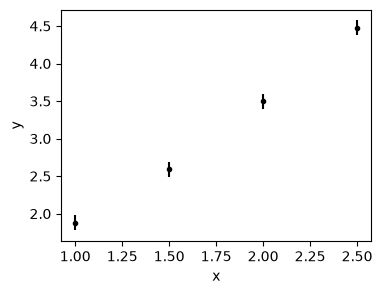

In [5]:
a_true, b_true = 0., 1.75
x = np.array([1, 1.5, 2, 2.5])
y = np.array([1.87640523, 2.59001572, 3.4978738, 4.47408932])
yerr = 0.1

plt.figure(figsize=(4, 3))
plt.errorbar(x, y, yerr=yerr, fmt='.k')
plt.xlabel('x'); plt.ylabel('y')
plt.show()

## Baseline: `emcee` (same as last class)

Same flat prior on $(a, b) \in [-10, 10]^2$, same likelihood, same ensemble sampler.

In [6]:
def model(theta, x):
    a, b = theta
    return a + b * x

def log_likelihood(theta, x, y, yerr):
    m = model(theta, x)
    return -0.5 * np.sum((y - m) ** 2 / yerr**2)

def log_prior(theta):
    a, b = theta
    if -10. < a < 10. and -10. < b < 10.:
        return 0.0
    return -np.inf

def log_posterior_np(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

re-implement emcee posterior sampling below

Optimization terminated successfully.
         Current function value: 0.901638
         Iterations: 45
         Function evaluations: 85
theta_MLE = [0.06430317 1.74016971]


100%|██████████| 3500/3500 [00:00<00:00, 3875.39it/s]


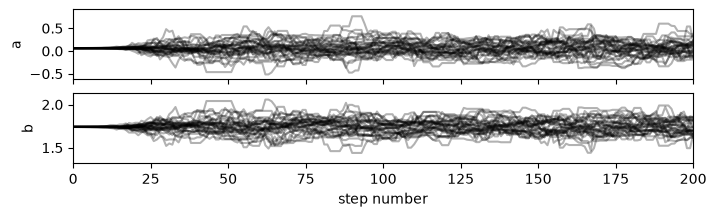

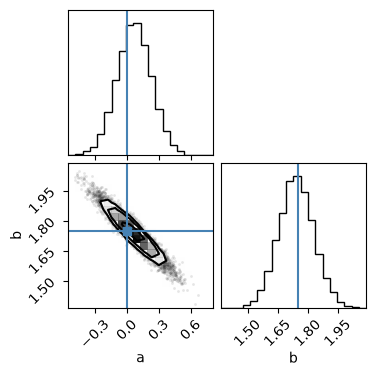

In [7]:
ndim, nwalkers = 2, 32
def model(theta, x):
    a, b = theta
    return a + b * x

def log_likelihood(theta, x, y, yerr):
    m = model(theta, x)
    return -0.5 * np.sum((y - m) ** 2 / yerr**2)

def log_prior(theta):
    a, b = theta
    if -10. < a < 10. and -10.0 < b < 10.0:
        return 0.0
    return -np.inf

def log_posterior(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp): return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

_p0 = sp.stats.norm(loc=1, scale=6)
_p1 = sp.stats.norm(loc=-2, scale=1)
def logp(x): # emcee takes in logp as input
    return np.log(0.5*(_p0.pdf(x) + _p1.pdf(x)))
theta_guess = [1., 1.] # initial guess 
def neg_log_likelihood(theta, x, y, yerr): 
    return -1 * log_likelihood(theta, x, y, yerr)
theta_est = sp.optimize.fmin(neg_log_likelihood, 
                             theta_guess, 
                             args=(x, y, yerr))
print('theta_MLE =', theta_est)

# create a small ball around the MLE the initialize each walker 
pos = theta_est + 1e-4 * np.random.randn(nwalkers, ndim)


sampler = emcee.EnsembleSampler(nwalkers, ndim, 
                                log_posterior, 
                                args=(x, y, yerr))
_ = sampler.run_mcmc(pos, 3500, progress=True)

fig, axes = plt.subplots(ndim, sharex=True, figsize=(8,2))
samples = sampler.get_chain()
labels = ["a", "b"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3, rasterized=True)
    ax.set_xlim(0, 200); ax.set_ylabel(labels[i])
axes[-1].set_xlabel("step number")

burnin = 100 
flat_samples = sampler.get_chain(discard=100, flat=True, thin=15)

fig = plt.figure(figsize=(4,4))
fig = corner.corner(flat_samples, labels=labels, 
                    truths=[a_true, b_true], fig=fig)
# initialize the walkers

# run EnsembleSampler

# discard burn-in then thin, and flatten chain
flat_emcee = sampler.get_chain(discard=burnin, flat=True, thin=15)

## sample using HMC NUTS

In [8]:
xj, yj = jnp.array(x), jnp.array(y)

def log_posterior_jax(params, x, y, yerr=0.1):
    # jax.numpy implementation oft he posterior
    a, b = params
    resid = y - (a + b * x)

    # we'll ignore the log-prior here because of its hard boundaries. 
    # a hard boundary has an undefined gradient exactly.
    # this won't be a problem because the likelihood alone pins the posterior firmly inside the bounds 
    return -0.5 * jnp.sum((resid / yerr) ** 2)

# wrap it into a lambda function to deal with args
logp_fn = lambda params: log_posterior_jax(params, xj, yj, yerr)

In [9]:
# random seeds
rng_key = jax.random.PRNGKey(0)
warmup_key, sample_key = jax.random.split(rng_key)

# run warm up to determine step size, epsilon 
warmup = blackjax.window_adaptation(blackjax.nuts, logp_fn)
(state, params), _ = warmup.run(warmup_key, jnp.array([1.0, 1.0]), num_steps=1000)

In [10]:
# run nuts
nuts = blackjax.nuts(logp_fn, **params)
final_state, (states, infos) = blackjax.util.run_inference_algorithm(
    sample_key, nuts, num_steps=3000, initial_state=state,
)

samples = np.array(states.position)
print('acceptance rate:', infos.acceptance_rate.mean())
print('mean:', samples.mean(axis=0))

acceptance rate: 0.94498956
mean: [0.0750636 1.7341384]


 Compare the HMC samples to the emcee samples using `corner`. Do they agree? 

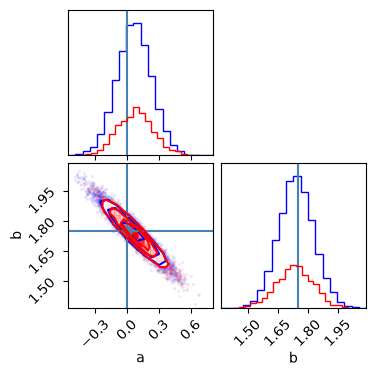

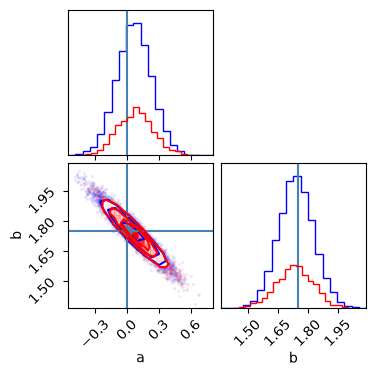

In [11]:
fig = plt.figure(figsize=(4,4))
fig = corner.corner(flat_samples, labels=labels, 
                    truths=[a_true, b_true], fig=fig,color='blue')
corner.corner(samples,fig=fig,color='red')

# fitting a model to data
Consider a more complex data below using the model 
$$y = a + b x + c x^2$$ 

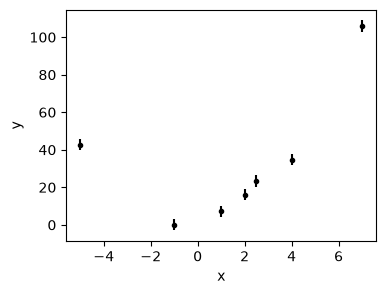

In [12]:
a_true, b_true, c_true = 0., 1.75, 2
x = np.array([-5, -1, 1, 2, 2.5, 4, 7])
yerr = 3
y = a_true + b_true * x + c_true * x**2 + np.random.normal(0, yerr, size=len(x))

plt.figure(figsize=(4, 3))
plt.errorbar(x, y, yerr=yerr, fmt='.k')
plt.xlabel('x'); plt.ylabel('y')
plt.show()

sample the likelihood **function** using MCMC with `emcee` and HMC+NUTS with `jax`+`blackjax`

In [20]:
xj, yj = jnp.array(x), jnp.array(y)

def jmodel(theta, x):
    a, b,c = theta
    return a + b * x +c*x**2

def log_like_jax(params, x, y, yerr=0.1):
    # implement the likelihood function in `jax.numpy`
    
    m = jmodel(params, x)
    return -0.5 *jnp.sum((y - m) ** 2 / yerr**2)

def log_like_j3(params, x, y, yerr=0.1):
    # implement the likelihood function in `jax.numpy`
    
    m = jmodel(params, x)
    return -0.5 *np.sum((y - m) ** 2 / yerr**2)

# wrap it into a lambda function to deal with args
loglike_fn = lambda params: log_like_jax(params, xj, yj, yerr)

implement MCMC with `emcee`

In [26]:
theta_guess = [1., 1.,1.] # initial guess 
ndim, nwalkers = 3, 32

def log_priorj3(params):
    a, b,c = params
    if -10. < a < 10. and -10. < b < 10. and -10. <c < 10.:
        return 0.0
    return -np.inf

def log_posterior_j3(params, x, y, yerr):
    lp = log_priorj3(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_like_j3(params, x, y, yerr)
    
def neg_log_likej3(params, x, y, yerr): 
    return -1 * log_like_j3(params, x, y, yerr)
    
theta_est = sp.optimize.fmin(neg_log_likej3,
                             theta_guess, 
                             args=(x, y, yerr))

pos = theta_est + 1e-4 * np.random.randn(nwalkers, ndim)


sampler = emcee.EnsembleSampler(nwalkers, ndim, 
                                log_posterior, 
                                args=(x, y, yerr))
_ = sampler.run_mcmc(pos, 3500, progress=True)

Optimization terminated successfully.
         Current function value: 3.330670
         Iterations: 141
         Function evaluations: 252
emcee: Exception while calling your likelihood function:
  params: [3.34521582 1.58038925 1.85906818]
  args: (array([-5. , -1. ,  1. ,  2. ,  2.5,  4. ,  7. ]), array([4.27155544e+01, 2.32848609e-02, 7.14488816e+00, 1.60594504e+01,
       2.34317262e+01, 3.48105110e+01, 1.05917659e+02]), 3)
  kwargs: {}
  exception:


Traceback (most recent call last):
  File "/home/asamcnaughton/miniconda3/envs/ast384/lib/python3.12/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_2971416/3539719598.py", line 17, in log_posterior
    lp = log_prior(theta)
         ^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_2971416/3539719598.py", line 11, in log_prior
    a, b = theta
    ^^^^
ValueError: too many values to unpack (expected 2)


ValueError: too many values to unpack (expected 2)

implement HMC+NUTS with `jax` and `blackjax`

In [16]:
# random seeds

# run warm up to determine step size, epsilon 

# run nuts

samples = np.array(states.position)
print('acceptance rate:', infos.acceptance_rate.mean())
print('mean:', samples.mean(axis=0))

acceptance rate: 0.94498956
mean: [0.0750636 1.7341384]


compare the two samples using `corner`